In [1]:
# Manipulación de datos
import os
import json
import numpy as np
import pandas as pd
from math import pi
import matplotlib.pyplot as plt
from datetime import timedelta
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pygam import LinearGAM, s

from Tools import Tools4DataExtraction as T4DE

In [2]:
D4NN= T4DE.Get_Data4NN_p()
#atributo='FECHA_CORRIDA'
atributo='FECHA_OPERACION'
D4NN[atributo] = pd.to_datetime(D4NN[atributo])
fecha_maxima = D4NN[atributo].max()
dia_anterior = fecha_maxima - timedelta(days=1)
bandera=False
if bandera:
    fecha_inicio = dia_anterior - timedelta(days=364)
    D4NN = D4NN[(D4NN[atributo] >= fecha_inicio) &
                        (D4NN[atributo] <= dia_anterior)].copy()
else:
    D4NN = D4NN[(D4NN[atributo] <= dia_anterior)].copy()

Memoria usada antes: 633.28 MB
Memoria usada después: 122.99 MB
Reducción: 80.6%


In [3]:
def load_and_aggregate(D4NN, target_col):
    """
    Agrupa por FECHA_CORRIDA y conserva columnas originales (sin PORCENT_PROMO).
    """
    Frame = D4NN[['FECHA_OPERACION', target_col, 'MES', 'FOP']].copy()
    agg_dict = {col: 'mean' for col in Frame.columns if col not in ['FECHA_OPERACION', target_col]}
    agg_dict[target_col] = 'sum'

    df = Frame.groupby('FECHA_OPERACION').agg(agg_dict)
    df.index = pd.to_datetime(df.index)
    return df.sort_index()

col= 'VENTA' 
df= load_and_aggregate(D4NN, col)

future_days= 15

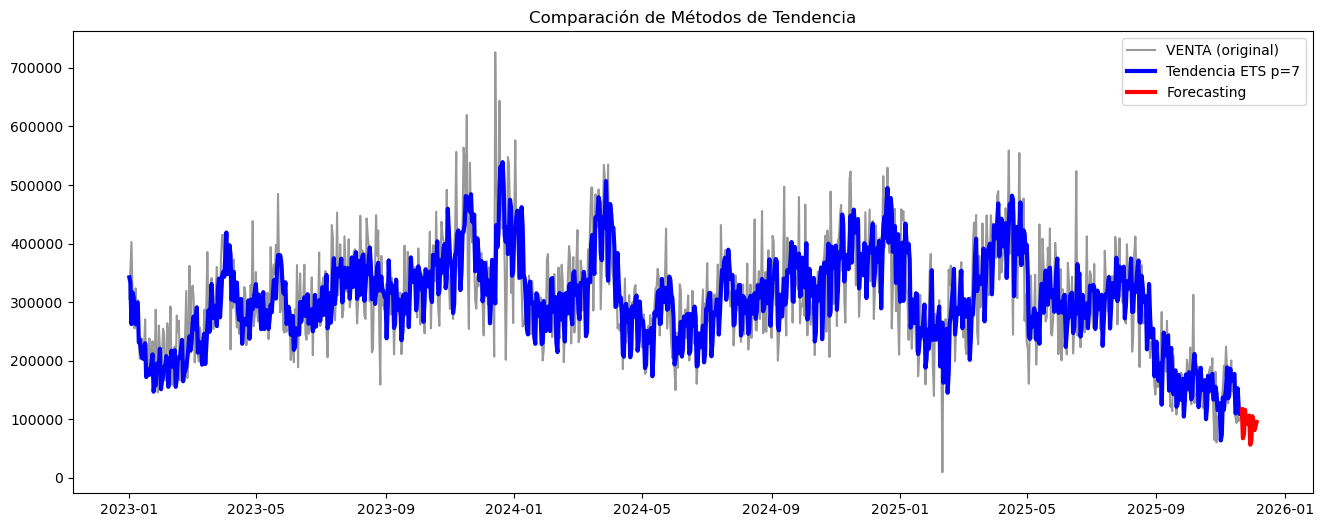

In [4]:
# ===========================
# 1. PREPARACIÓN DE DATOS
# ===========================
df_1=df[['VENTA']].copy()
# ===========================
# ETS (Holt-Winters sin estacionalidad)
# ===========================
ets_model = ExponentialSmoothing(df_1, trend='add',damped_trend=False, seasonal='add',seasonal_periods=7)
ets_fit = ets_model.fit()
ets_trend = ets_fit.fittedvalues
forecast_ETS= ets_fit.forecast(future_days)
# ===========================
# 5. GRÁFICAS DE COMPARACIÓN
# ===========================

plt.figure(figsize=(16,6))

plt.plot(df.index, df['VENTA'], color='black',alpha=0.4, label='VENTA (original)')
plt.plot(df.index, ets_trend, label='Tendencia ETS p=7', linewidth=3,color='blue')
plt.plot(forecast_ETS.index, forecast_ETS, label='Forecasting', linewidth=3,color='red')

plt.legend()
plt.title("Comparación de Métodos de Tendencia")
plt.show()


In [5]:
df_1['VENTA'].values

array([305661.8 , 355525.2 , 402932.03, ...,  96754.43, 101282.87,
       102711.11], dtype=float32)

In [6]:
#resid= df_1['VENTA'].values-ets_trend.values
# Extraer los residuos
resid = ets_fit.resid
residual = pd.DataFrame(resid, columns=['residuos'])
residual.index=df_1.index

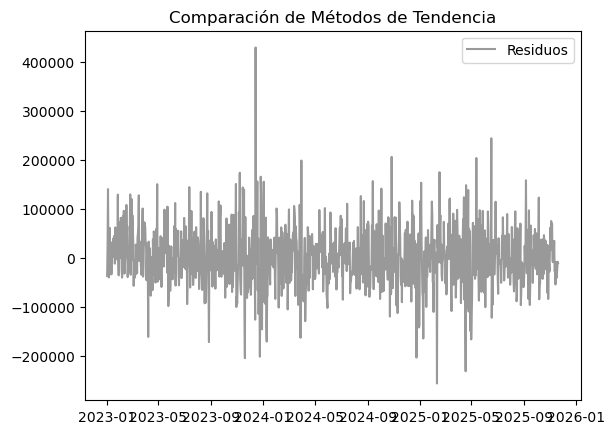

In [7]:
plt.plot(residual.index, residual['residuos'], color='black',alpha=0.4, label='Residuos')
plt.legend()
plt.title("Comparación de Métodos de Tendencia")
plt.show()


<Figure size 1200x400 with 0 Axes>

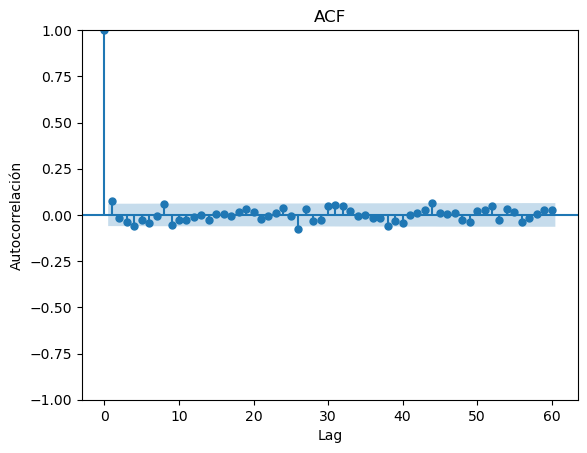

<Figure size 1200x400 with 0 Axes>

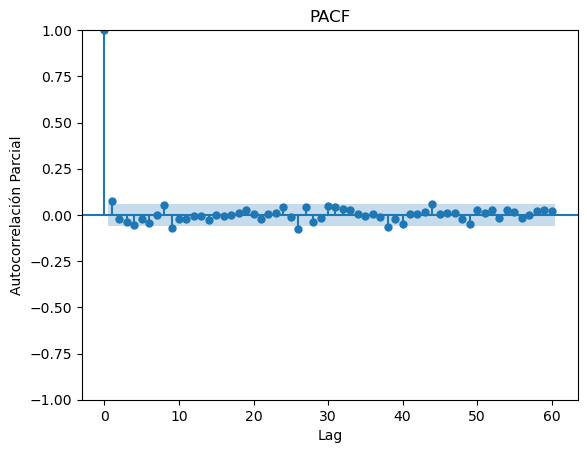

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 2. Gráfica de Autocorrelación (ACF) ---
plt.figure(figsize=(12, 4))
plot_acf(resid, lags=60, title='ACF')
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.show()

# --- 3. Gráfica de Autocorrelación Parcial (PACF) ---
plt.figure(figsize=(12, 4))
plot_pacf(resid, lags=60, title='PACF')
plt.xlabel("Lag")
plt.ylabel("Autocorrelación Parcial")
plt.show()

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# si p_val > 0.05 no es ruido blanco
lags = [5, 10, 15, 20,25,30]
result = acorr_ljungbox(resid, lags=lags, return_df=True)
print(result)

      lb_stat  lb_pvalue
5   12.015216   0.034580
10  21.998497   0.015112
15  23.525284   0.073606
20  25.187491   0.194352
25  27.468897   0.332874
30  39.635811   0.112113


In [10]:
from scipy.stats import shapiro
# si p_val > 0.05 tiene distribución normal

stat, p = shapiro(resid)
print(f"p-valor: {p}")

p-valor: 7.948542593671786e-13


In [13]:
from arch import arch_model

# Crear el objeto GARCH, especificando los residuos como datos
# mean='constant': Modelamos la media de los residuos (que es ~0)
# vol='Garch': Especificamos el tipo de modelo de volatilidad
# p=1, q=1: Usamos GARCH(1,1)
modelo_garch = arch_model(resid, mean='constant', vol='Garch', p=1, q=1)

# Ajustar el modelo (estima los parámetros omega, alpha y beta)
garch_ajustado = modelo_garch.fit(disp='off')

# Estimate the volatility
volatility = garch_ajustado.conditional_volatility

# Pronóstico de la varianza para los próximos 10 pasos
pronostico_garch = garch_ajustado.forecast(horizon=future_days, reindex=True)

# La volatilidad pronosticada es la raíz cuadrada de la varianza pronosticada
volatilidad_pronosticada = pronostico_garch.variance.iloc[-1].apply(lambda x: x**0.5)

In [20]:
volatilidad_pronosticada.values, forecast_ETS.values

(array([45813.34149382, 46156.68932647, 46490.78932969, 46815.9712676 ,
        47132.54802719, 47440.816826  , 47741.06030805, 48033.5475407 ,
        48318.53492326, 48596.2670168 , 48866.97730347, 49130.88888271,
        49388.21511062, 49639.16018818, 49883.91970336]),
 array([117218.11305916,  67472.96515016,  74165.33433977, 116107.75862347,
         96878.37664982,  92266.32708335,  99139.4708419 , 106229.35530077,
         56484.20739177,  63176.57658138, 105119.00086507,  85889.61889143,
         81277.56932496,  88150.71308351,  95240.59754237]))

In [23]:
Df_Futuro=pd.DataFrame()
Df_Futuro['Forecasting']= forecast_ETS.values
Df_Futuro['Volatility']= volatilidad_pronosticada.values
Df_Futuro['Fore_Up']= forecast_ETS.values + volatilidad_pronosticada.values
Df_Futuro['Fore_Low']= forecast_ETS.values - volatilidad_pronosticada.values
Df_Futuro.index= forecast_ETS.index

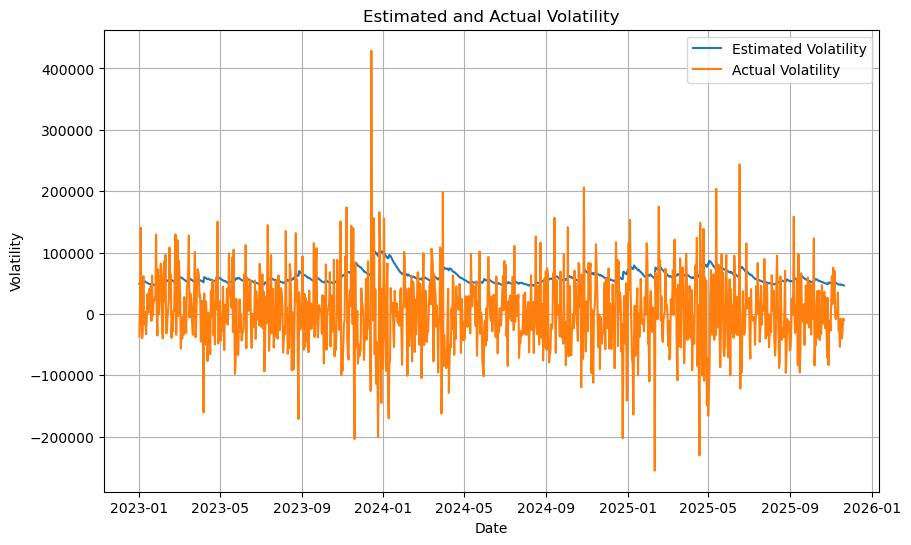

In [14]:
# Plot the estimated and actual volatility
plt.figure(figsize=(10, 6))
plt.plot(volatility.index, volatility, label="Estimated Volatility")
plt.plot(resid.index, resid, label="Actual Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Estimated and Actual Volatility")
plt.legend()
plt.grid(True)

plt.show()

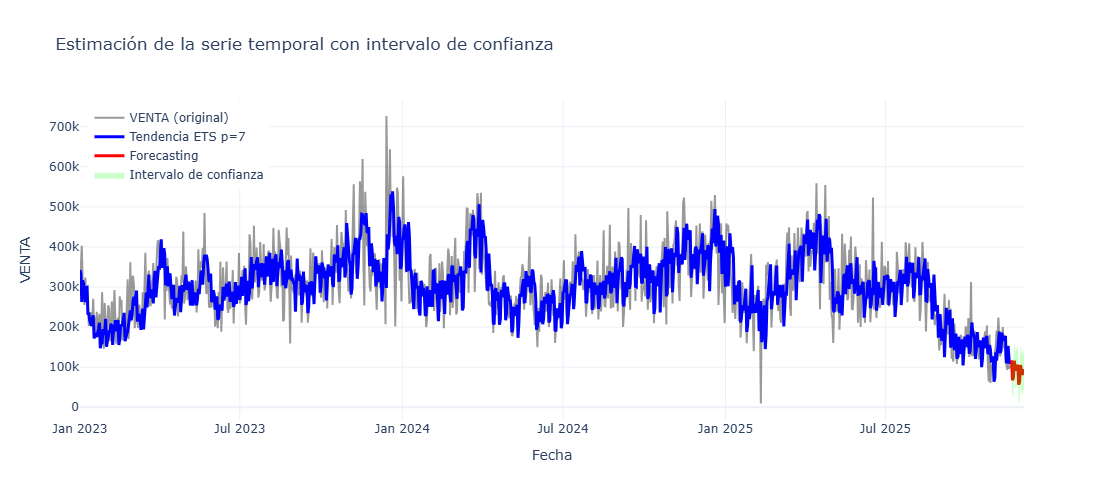

In [28]:
import plotly.graph_objects as go

fig = go.Figure()

# Serie original
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['VENTA'],
    mode='lines',
    name='VENTA (original)',
    line=dict(color='black', width=2),
    opacity=0.4
))

# Tendencia ETS
fig.add_trace(go.Scatter(
    x=df.index,
    y=ets_trend,
    mode='lines',
    name='Tendencia ETS p=7',
    line=dict(color='blue', width=3)
))

# Pronóstico
fig.add_trace(go.Scatter(
    x=Df_Futuro.index,
    y=Df_Futuro['Forecasting'],
    mode='lines',
    name='Forecasting',
    line=dict(color='red', width=3)
))

# Intervalo de confianza (área sombreada)
fig.add_trace(go.Scatter(
    x=list(Df_Futuro.index) + list(Df_Futuro.index[::-1]),
    y=list(Df_Futuro['Fore_Up']) + list(Df_Futuro['Fore_Low'][::-1]),
    fill='toself',
    fillcolor='rgba(0, 255, 0, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Intervalo de confianza'
))

fig.update_layout(
    title="Estimación de la serie temporal con intervalo de confianza",
    xaxis_title="Fecha",
    yaxis_title="VENTA",
    template="plotly_white",
    legend=dict(x=0.01, y=0.99),
    hovermode="x unified",
    width=1000,
    height=500
)

fig.show()